# A tutorial for NuQuLib 

- (1) Hamiltonian mapping
    - a. Jordan-Wigner mapping of nuclear Hamiltonians
    - b. Pairing Hamiltonian
    - c. comparison with Chemical Hamiltonians
- (2) VQE with UCC ansatz
- (3) Algorithms with Time-evolution
    - a. Time-evolution with Trotterization
    - b. resource estimation for (E-)FTQC methods
        - QPE
        - Qkrylov
        - ODMD
    - c. QSCI/SQD demo for small systems
- (4) ODMD examples for two-neutron systems

## Pre-requisites



In [1]:
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2
from qiskit_algorithms.optimizers import SLSQP, NFT, L_BFGS_B, ADAM
from qiskit_algorithms.minimum_eigensolvers import AdaptVQE, VQE
from qiskit_ibm_runtime.fake_provider import FakeTorino
from qiskit_nature.second_q.circuit.library.ansatzes import UCC
from qiskit.primitives import Estimator
import seaborn as sns
cols_hist = sns.color_palette("deep")


## To run the demo codes: virtual environment

After a certain version for Python and pip (around 3.11),
the Python community proposed [PEP 668](https://peps.python.org/pep-0668/) for managing python packages.
Users are now strongly recommended to use virtual environments to avoid conflicts between packages and conflicts with the system itself.

You can create a virtual environment with the following command:

```bash
$python3 -m venv name_of_your_env
```

Then, you can activate the virtual environment with the following command:

```bash
$source path_to_your_env/bin/activate
```

After activating the virtual environment, you can install the required packages with the following command:

```bash
$pip install package_name
```

or 

```bash
$pip install -r requirements.txt
```

if `requirements.txt` is provided in the repository.


In the following, we assume you already have cloned `nuqulib` module and using `pip`.

```bash
source path_to_your_venv/bin/activate
pip install -r /path_to_nuqulib/requirements.txt
pip install -e /path_to_NuQuLib
```

In [2]:
from nuqulib import *
#int_file_path = "interaction_file/"
int_file_path = "tests/interaction_file/"

## (1) Hamiltonian mapping

### (1)-a: Jordan-Wigner mapping of nuclear Hamiltonians

In the following, we demonstrate the usage of the `NuQuLib` package by taking smaller systems with only a few (valence) nucleons.

First, we read `ckpot` effective interaction for 0p shell (p1/2 and p3/2 orbitals on top of 4He core) and map it to the qubit Hamiltonian using Jordan-Wigner transformation.

NuQuLib allows to read the interaction files for NN and 3N interactions in e.g. `snt` (`kshell.snt` in NuHamil code) format.
One can check the mapping is correct by comparing the energy of the ground state of fully occupied systems in the specified model space.

In the following, we will see both valence (p, sd, pf) and NCSM (emax=0, 1) cases give correct results.

#### valence space

We will consider the following fully occupied systems in the valence shell model spaces:

1. 16O in p shell
2. 40Ca in sd shell


In [3]:
fns = ["ckpot.snt", "usdb.snt"]
ZNs = [ (8, 8), (20, 20) ]

for idx in range(len(fns)):
    filename_snt = int_file_path + fns[idx]
    print("filename_snt:", filename_snt)
    Z, N = ZNs[idx]
    hamil = Hamiltonian(filename_snt, Z, N)

    mapping_method = "JordanWigner"
    hamil.get_mscheme_H(opform=True)
    H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
    H_1b = H_1b_p + H_1b_n

    n_qubits = hamil.n_qubits
    qc = QuantumCircuit(n_qubits)
    qc.x(range(n_qubits))  # prepare all qubits in |1> state

    # measurement of Hamiltonian
    estimator = StatevectorEstimator()
    job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn)])
    results = job.result()
    E_1b, E_pp, E_nn, E_pn = [ results[i].data.evs for i in range(len(results))]
    E_total = E_1b + E_pp + E_nn + E_pn 
    print("Etot", E_total, "E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn)


filename_snt: tests/interaction_file/ckpot.snt


0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


...

# of H_m terms, 1b: 24, 2b pp: 613, nn: 613, pn: 3618 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 9513


9513it [00:00, 241403.72it/s]


Etot -279.9607012333838 E_1b:  -43.04640000000002 <pp> -15.600464041796155 <nn> -15.600464041796155 <pn> -205.71337314979147


#### NCSM (No-core shell model) space

NN interaction is the so-called EM500 with SRG (1.8 fm^{-1} cutoff) and HO basis with hw=20 MeV and emax=1.
The 3N interaction called local-nonlocal (lnl) interaction is used.

Detailed parameters are ...

One should keep in mind that the results will change depending on the choice of the interaction and the settings to generate the Hamiltonian.
Within these settings, the ground state energy of ${}^{16}\text{O}$ would be -131.83565 MeV.

In [4]:
emax = 1
filename_snt = int_file_path + "TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax1_e2max2.kshell.snt"
fn_3NF = int_file_path + "ThBME_lnl_ms1_2_1.readable.txt"
Z = proton_number  = N = neutron_number = 8

hamil = Hamiltonian(filename_snt, Z, N, ncsm=True, verbose=False, emax_truncate=emax,
                    e3max=emax, fn_3NF=fn_3NF)
mapping_method = "JordanWigner"
hamil.get_mscheme_H(opform=True)
H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
H_1b = H_1b_p + H_1b_n

Hamil_NCSM_NN = H_1b + H_pp + H_nn + H_pn
hamil.set_mscheme_3NF()
H_3b = hamil.mapping_3NF_Mscheme()
Hamil_NCSM_NN3NF = Hamil_NCSM_NN + H_3b

n_qubits = hamil.n_qubits
qc = QuantumCircuit(n_qubits)
qc.x(range(n_qubits))  # prepare all qubits in |1> state

# measurement of Hamiltonian
estimator = StatevectorEstimator()
job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn), (qc, H_3b)])
results = job.result()
E_1b, E_pp, E_nn, E_pn, E_3n = [ results[i].data.evs for i in range(len(results))]
E_total = E_1b + E_pp + E_nn + E_pn + E_3n
print("Etot", E_total, "E(NN)", E_1b + E_pp + E_nn + E_pn)
print("E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn, "<3b>", E_3n)

Setting up 3NF matrix elements in mscheme...


100%|██████████| 408/408 [00:00<00:00, 21626.41it/s]


Total number of 3NF matrix elements in M-scheme 10800


100%|██████████| 10800/10800 [00:00<00:00, 831210.58it/s]


# of H_m terms, 1b: 16, 2b pp: 66, nn: 66, pn: 456 v3b 1552


...

Total number of 3NF matrix elements in M-scheme 10800


100%|██████████| 1552/1552 [00:02<00:00, 775.81it/s]


Removing redundant terms... len= 35200 => 

100%|██████████| 35200/35200 [00:00<00:00, 6981581.35it/s]


1467
Etot -131.83565105910446 E(NN) -148.36878574000008
E_1b:  337.5 <pp> -53.04027523999999 <nn> -70.00286418000003 <pn> -362.8256463200001 <3b> 16.533134680895618


### (1)-b: Pairing Hamiltonian (JW)

Pairing Hamiltonian is a simplified model of the nuclear interaction or a simplified model of BCS pairing. The Hamiltonian with a global pairing interaction is given by

$$
H = \sum_{i} \epsilon_i a_i^{\dagger} a_i - \frac{g}{4} \sum{i,j} a_i^{\dagger} a_{\bar{i}}^{\dagger} a_{\bar{j}} a_j
$$

where $a_i^{\dagger}$ and $a_i$ are the creation and annihilation operators for the nucleon in the $i$-th orbital, $\epsilon_i$ is the single-particle energy of the $i$-th orbital, $g$ is the pairing strength, and $\bar{i}$ is the time-reversed orbital of $i$.

In [5]:
Norb = 12
Nocc = 6
gval = 0.33
hamil = PairingHamiltonian(Norb, Nocc, gval)
Hamil_Pairing = hamil.encoding()

# Make a time evolution operator U = exp(-iHt)
delta_t = 0.1
Unitary_P = PauliEvolutionGate(Hamil_Pairing, delta_t, synthesis=SuzukiTrotter(order=1,reps=1))
print("U:", Unitary_P)

# Make a quantum circuit (1 ancilla + target qubits)
qc = QuantumCircuit(Norb+1)
Unitary_P = Unitary_P.control(1)
qc.append(Unitary_P, range(Norb+1))
qc = qc.decompose(reps=5)
print("# of gates, raw circuit:", qc.count_ops())

U: Instruction(name='PauliEvolution', num_qubits=12, num_clbits=0, params=[0.1])
# of gates, raw circuit: OrderedDict({'u': 5305, 'cx': 2928})


### (1)-c: Chemical Hamiltonians 

According to the Pennylane documentation [here](https://docs.pennylane.ai/en/stable/introduction/chemistry.html), `qchem` module provides molecular Hamiltonians.

One can specify the molecule by its symbols and geometry, and then the Hamiltonian can be generated using the `qml.qchem.molecular_hamiltonian` function.

Similarly, Qiskit provides molecular Hamiltonians via e.g. `qiskit_nature` module.

In [6]:
symbols = ["Li", "H"]
geometry = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 2.969280527]])
molecule = qml.qchem.Molecule(symbols, geometry)
H, qubits = qml.qchem.molecular_hamiltonian(
    molecule,
    active_electrons=2,
    active_orbitals=5,
)
def circuit(params):
    qml.ApproxTimeEvolution(H, time=0.1, n=1)
    return [qml.expval(qml.PauliZ(i)) for i in range(qubits)]

dev = qml.device("default.qubit", wires=qubits)
params = np.random.rand(qubits)
compiled_qnode = qml.compile(
    qml.QNode(circuit, device=dev),
    basis_set=["CNOT", "RX", "RY", "RZ"])

spec = qml.specs(compiled_qnode)(params)

print("qubits:", qubits, "Gates:", dict(spec["resources"].gate_types))

qubits: 10 Gates: {'RZ': 1437, 'RX': 1186, 'CNOT': 2356}


## (2): VQE with UCC ansatz



The key components of the VQE algorithm is to prepare a trial wavefunction, given as parametrized quantum circuit, and to minimize the expectation value of the Hamiltonian with respect to this wavefunction.

We adopt the unitary coupled cluster (UCC) ansatz here.

To start rather arbitrarily, let us define a function to generate excitation operators on top of a naive filling configuration. This will be referred in the UCC class, so it should be defined in this manner.

In [7]:
def custom_excitation_list(num_spatial_orbitals, num_particles):
    global hole_p, particle_p, hole_n, particle_n
    my_custom_excitations = [ ]
    ## Single excitations
    for h_p in hole_p:
        for p_p in particle_p:
            my_custom_excitations.append( ((h_p,), (p_p,)) )
    for h_n in hole_n:
        for p_n in particle_n:
            my_custom_excitations.append( ((h_n,), (p_n,)) )

    ## pp doubles
    for h_p_1 in hole_p:
        for h_p_2 in hole_p:
            if h_p_1 == h_p_2: continue
            for p_p_1 in particle_p:
                for p_p_2 in particle_p:
                    if p_p_1 == p_p_2: continue
                    my_custom_excitations.append( ((h_p_1, h_p_2), (p_p_1, p_p_2)) )
    ## nn doubles
    for h_n_1 in hole_n:
        for h_n_2 in hole_n:
            if h_n_1 == h_n_2: continue
            for p_n_1 in particle_n:
                for p_n_2 in particle_n:
                    if p_n_1 == p_n_2: continue
                    my_custom_excitations.append( ((h_n_1, h_n_2), (p_n_1, p_n_2)) )
    ## pn doubles
    for h_p in hole_p:
        for h_n in hole_n:
            for p_p in particle_p:
                for p_n in particle_n:
                    my_custom_excitations.append( ((p_p, p_n), (h_p, h_n)) )
    return my_custom_excitations

### 6He (2n on 0p shell)

Egs (J=0) =  -3.90981 MeV

In [8]:
np.random.seed(42)  
fn = int_file_path+"ckpot.snt"
Z = 0; N = 2
Hamil_Shellmodel, H_JW, proton_qubits, neutron_qubits = get_Hamiltonian(fn, Z, N)
n_qubits = Hamil_Shellmodel.n_qubits
mapper = JordanWignerMapper()

# Define the initial state&UCC ansatz
init_state = QuantumCircuit(n_qubits)
init_state.x(9); init_state.x(10); hole_p = [ ]; hole_n = [9, 10]

particle_p = [q for q in proton_qubits if q not in hole_p]
particle_n = [q for q in neutron_qubits if q not in hole_n]

display(init_state.draw())

vqe_ansatz = UCC(
    n_qubits//2,
    num_particles=(Z, N),
    initial_state=init_state,
    qubit_mapper = mapper,
    preserve_spin=True,
    reps=1,
    excitations = custom_excitation_list
)

optimizer = SLSQP(maxiter=200)
print("Number of parameters: ", vqe_ansatz.num_parameters)
print("vqe.excitations: ", vqe_ansatz._excitation_list)
print("Gate counts:", vqe_ansatz.decompose(reps=5).count_ops())

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)

counts = []
values = []
vqe = VQE(Estimator(), vqe_ansatz, optimizer, callback=store_intermediate_result)
vqe.initial_point = np.random.normal(0, 0.1, vqe_ansatz.num_parameters)
vqe_result = vqe.compute_minimum_eigenvalue(H_JW)
binding_energy = vqe_result.optimal_value
print("E(VQE) = ", binding_energy)

0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


777it [00:00, 207208.43it/s]


q_0: ─────
           
 q_1: ─────
           
 q_2: ─────
           
 q_3: ─────
           
 q_4: ─────
           
 q_5: ─────
           
 q_6: ─────
           
 q_7: ─────
           
 q_8: ─────
      ┌───┐
 q_9: ┤ X ├
      ├───┤
q_10: ┤ X ├
      └───┘
q_11: ─────

Number of parameters:  32
vqe.excitations:  [((9,), (6,)), ((9,), (7,)), ((9,), (8,)), ((9,), (11,)), ((10,), (6,)), ((10,), (7,)), ((10,), (8,)), ((10,), (11,)), ((9, 10), (6, 7)), ((9, 10), (6, 8)), ((9, 10), (6, 11)), ((9, 10), (7, 6)), ((9, 10), (7, 8)), ((9, 10), (7, 11)), ((9, 10), (8, 6)), ((9, 10), (8, 7)), ((9, 10), (8, 11)), ((9, 10), (11, 6)), ((9, 10), (11, 7)), ((9, 10), (11, 8)), ((10, 9), (6, 7)), ((10, 9), (6, 8)), ((10, 9), (6, 11)), ((10, 9), (7, 6)), ((10, 9), (7, 8)), ((10, 9), (7, 11)), ((10, 9), (8, 6)), ((10, 9), (8, 7)), ((10, 9), (8, 11)), ((10, 9), (11, 6)), ((10, 9), (11, 7)), ((10, 9), (11, 8))]
Gate counts: OrderedDict({'u3': 2400, 'cx': 1480, 'u': 1010})


/var/folders/1z/x2pvmpxs7n1dsrqgqm2d52g00000gn/T/ipykernel_23096/3999400895.py:38: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), vqe_ansatz, optimizer, callback=store_intermediate_result)


E(VQE) =  -3.9098123160552904


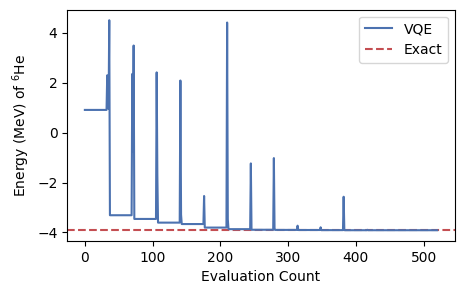

In [9]:
counts_vqe = list(counts)
values_vqe = list(values)
Eexact =  -3.90981
fig = plt.figure(figsize=(5, 3))
plt.plot(values_vqe, color=cols_hist[0], label='VQE', zorder=1)
plt.axhline(y=Eexact, color=cols_hist[3], linestyle='--', label='Exact', zorder=0)
plt.xlabel('Evaluation Count')
plt.ylabel('Energy (MeV) of $^6$He')
plt.legend()
plt.rcParams["font.size"] = 14
plt.savefig("vqe_energy_6He.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

### 6Li (p-n on 0p shell)

Egs = -5.43299 MeV (J=1)

In [10]:
np.random.seed(42)  

fn = int_file_path + "ckpot.snt"
Z = N = 1
Hamil_Shellmodel, H_JW, proton_qubits, neutron_qubits = get_Hamiltonian(fn, Z, N)
n_qubits = Hamil_Shellmodel.n_qubits
mapper = JordanWignerMapper()

# Define the initial state&UCC ansatz
init_state = QuantumCircuit(n_qubits)
init_state.x(3); init_state.x(10); hole_p = [3]; hole_n = [10]

particle_p = [q for q in proton_qubits if q not in hole_p]
particle_n = [q for q in neutron_qubits if q not in hole_n]

display(init_state.draw())

vqe_ansatz = UCC(
    n_qubits//2,
    num_particles=(Z, N),
    initial_state=init_state,
    qubit_mapper = mapper,
    preserve_spin=True,
    reps=1,
    excitations = custom_excitation_list
)

optimizer = SLSQP(maxiter=200)
print("Number of parameters: ", vqe_ansatz.num_parameters)


def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)

counts = []
values = []
vqe = VQE(Estimator(), vqe_ansatz, optimizer, callback=store_intermediate_result)
vqe.initial_point = np.random.normal(0, 0.1, vqe_ansatz.num_parameters)
vqe_result = vqe.compute_minimum_eigenvalue(H_JW)
binding_energy = vqe_result.optimal_value
#print("Parameters: ", vqe_result.optimal_point)

print("E(VQE) = ", binding_energy)
print("Gate counts:", vqe_ansatz.decompose(reps=5).count_ops())

0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


777it [00:00, 196252.81it/s]


q_0: ─────
           
 q_1: ─────
           
 q_2: ─────
      ┌───┐
 q_3: ┤ X ├
      └───┘
 q_4: ─────
           
 q_5: ─────
           
 q_6: ─────
           
 q_7: ─────
           
 q_8: ─────
           
 q_9: ─────
      ┌───┐
q_10: ┤ X ├
      └───┘
q_11: ─────

Number of parameters:  35


/var/folders/1z/x2pvmpxs7n1dsrqgqm2d52g00000gn/T/ipykernel_23096/861936726.py:38: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), vqe_ansatz, optimizer, callback=store_intermediate_result)


E(VQE) =  -5.008799896662552
Gate counts: OrderedDict({'u3': 2520, 'cx': 2080, 'u': 1062})


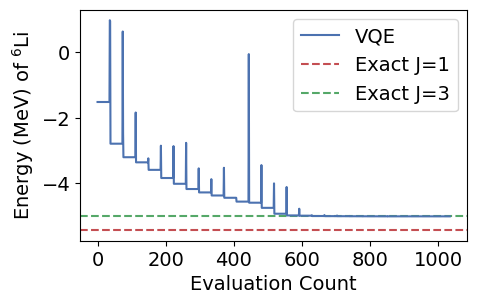

In [11]:
counts_vqe = list(counts)
values_vqe = list(values)
Egs = -5.43299
Eex1 = -5.008799945408569
fig = plt.figure(figsize=(5, 3))
plt.plot(values_vqe, color=cols_hist[0], label='VQE', zorder=1)
plt.axhline(y=Egs, color=cols_hist[3], linestyle='--', label='Exact J=1', zorder=0)
plt.axhline(y=Eex1, color=cols_hist[2], linestyle='--', label='Exact J=3', zorder=0)
plt.xlabel('Evaluation Count')
plt.ylabel('Energy (MeV) of $^6$Li')
plt.legend()
plt.rcParams["font.size"] = 14
plt.savefig("vqe_energy_6Li.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

While 6He (2n in 0p shell) is reproduced correctly, 6Li (p-n) is not.

Since both proton and neutron degrees of freedom are involved, the circuit becomes a bit complicated and deeper than the 6He case.
Even in such a small system, one can easily get stuck in local minima, E= -5.00880 (J=3) state, instead of the true g.s. -5.43299 (J=1).

Another possibility to reduce the circuit depth is to use the adaptive VQE (Adapt-VQE) algorithm, which adaptively selects the excitation operators from the pool of all possible excitations based on the gradient of the energy.
In that case, one should also be careful about the initialization of the trial wavefunction, optimization method, etc.

See also [O.Kiss et al.: Quantum computing of the 6Li nucleus via ordered unitary coupled clusters, Phys. Rev. C 106, 034325 (2022)]( https://doi.org/10.1103/PhysRevC.106.034325).

## (3) Algorithms with Time-evolution

### (3)-a: Time-evolution with Trotterization

Time-evolution is a key component of many quantum algorithms.
By means of time-evolution, constructed via Trotterization, one can implement various quantum algorithms such as quantum phase estimation (QPE), quantum Krylov (Qkrylov), and observable dynamic mode decomposition (ODMD).

In the following, only the first order and single step Suzuki-Trotter decomposition is used:

$$
\hat{U}(t) = e^{-i \hat{H} t} \approx e^{-i \hat{H}_1 t} e^{-i \hat{H}_2 t} \cdots e^{-i \hat{H}_n t}
$$

where $\hat{H}_i$ are the terms in the Hamiltonian given as e.g. Qiskit's `SparsePauliOp` object containing the Pauli strings and their (real) coefficients.


Taking NCSM Hamiltonian as an example, we show a sample code to perform time-evolution with Trotterization.


In [12]:
fn_2NF = int_file_path+"TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax1_e2max2.kshell.snt"
fn_3NF = int_file_path+"ThBME_lnl_ms1_2_1.readable.txt"
Z = N = 3 

hamil = Hamiltonian(fn_2NF, Z, N, ncsm=True, verbose=False, emax_truncate=emax, e3max=emax, fn_3NF=fn_3NF)
mapping_method = "JordanWigner"
hamil.get_mscheme_H(opform=True)

H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
H_1b = H_1b_p + H_1b_n
Hamil_NN = H_1b + H_pp + H_nn + H_pn

hamil.set_mscheme_3NF()
H_3b = hamil.mapping_3NF_Mscheme()
Hamil_NN3NF = Hamil_NN + H_3b

dt = 0.1
trotter_steps = 1
U_NN = PauliEvolutionGate(Hamil_NN, dt, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
U_3N = PauliEvolutionGate(Hamil_NN3NF, dt, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))

qc = QuantumCircuit(hamil.n_qubits)
qc.append(U_NN, range(hamil.n_qubits))
qc = qc.decompose(reps=5)
print("# of gates (NN-only):", qc.count_ops())

qc = QuantumCircuit(hamil.n_qubits)
qc.append(U_3N, range(hamil.n_qubits))
qc = qc.decompose(reps=5)
print("# of gates (NN+3NF): ", qc.count_ops())

Setting up 3NF matrix elements in mscheme...


100%|██████████| 408/408 [00:00<00:00, 23932.59it/s]


Total number of 3NF matrix elements in M-scheme 10800


100%|██████████| 10800/10800 [00:00<00:00, 836799.79it/s]


# of H_m terms, 1b: 16, 2b pp: 66, nn: 66, pn: 456 v3b 1552


...

Total number of 3NF matrix elements in M-scheme 10800


100%|██████████| 1552/1552 [00:01<00:00, 797.73it/s]


Removing redundant terms... len= 35200 => 

100%|██████████| 35200/35200 [00:00<00:00, 6359659.74it/s]


1467
# of gates (NN-only): OrderedDict({'u': 25096, 'cx': 18256})
# of gates (NN+3NF):  OrderedDict({'u': 50242, 'cx': 32348})


#### HATTMapper

In [13]:
fn_2NF = int_file_path+"TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax1_e2max2.kshell.snt"
fn_3NF = int_file_path+"ThBME_lnl_ms1_2_1.readable.txt"
Z = N = 3 

hamil = Hamiltonian(fn_2NF, Z, N, ncsm=True, verbose=False, emax_truncate=emax, e3max=emax, fn_3NF=fn_3NF)
mapping_method = "HATTMapper"
filepath = "HATT_Li6"
hamil.get_mscheme_H(opform=True)

H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method, filepath=filepath)
H_1b = H_1b_p + H_1b_n
Hamil_NN = H_1b + H_pp + H_nn + H_pn

hamil.set_mscheme_3NF()
H_3b = hamil.mapping_3NF_Mscheme()
Hamil_NN3NF = Hamil_NN + H_3b

dt = 0.1
trotter_steps = 1
U_NN = PauliEvolutionGate(Hamil_NN, dt, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
U_3N = PauliEvolutionGate(Hamil_NN3NF, dt, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))

qc = QuantumCircuit(hamil.n_qubits)
qc.append(U_NN, range(hamil.n_qubits))
qc = qc.decompose(reps=5)
print("# of gates (NN-only):", qc.count_ops())

qc = QuantumCircuit(hamil.n_qubits)
qc.append(U_3N, range(hamil.n_qubits))
qc = qc.decompose(reps=5)
print("# of gates (NN+3NF): ", qc.count_ops())

Setting up 3NF matrix elements in mscheme...


100%|██████████| 408/408 [00:00<00:00, 24179.10it/s]


Total number of 3NF matrix elements in M-scheme 10800


100%|██████████| 10800/10800 [00:00<00:00, 832937.69it/s]


# of H_m terms, 1b: 16, 2b pp: 66, nn: 66, pn: 456 v3b 1552


...

Total number of 3NF matrix elements in M-scheme 10800


100%|██████████| 1552/1552 [00:02<00:00, 749.41it/s]


Removing redundant terms... len= 35200 => 

100%|██████████| 35200/35200 [00:00<00:00, 6302646.78it/s]


1467
# of gates (NN-only): OrderedDict({'u': 30184, 'cx': 17920})
# of gates (NN+3NF):  OrderedDict({'u': 55330, 'cx': 32012})


### (3)-b: resource estimation for (E-)FTQC methods

#### Quantum Phase Estimation (QPE)

QPE is the most fundamental quantum algorithm to estimate the eigenvalues of a Hamiltonian, i.e. interacting quantum many-body system.

The basic idea is to prepare register qubits, called ancilla qubits, to extract the eigenvalues of the Hamiltonian by means of controlled time-evolution.
The number of ancilla qubits determines the precision of the eigenvalue estimation, i.e. the number of bits in the binary representation of the eigenvalue.
If one adds one ancilla qubit, the precision is doubled, i.e. one can estimate the eigenvalue up to $2^{-1}$.
However, adding one ancilla qubit requires an additional controlled time-evolution gate and thus increases the circuit depth.

Under the given number of ancilla qubits, $N_a$, the required time-evolution operator is given as

$$
\sum_{k=0}^{N_a-1} \hat{U}^{2^k}
$$

In the case of $N_a=10$, the number of controlled $U$ operation becomes 1024-1=1023.
This scaling prohibits the direct implementation of QPE for large systems in current quantum computers.


In [14]:
def resource_estimation_QPE(N_a, N_q, H_mapped, dt, trotter_steps=1):
    Unitary = PauliEvolutionGate(H_mapped, dt, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
    # We don't construct the full circuit here, just construct a single controlled unitary    
    qc = QuantumCircuit(1+N_q)
    cU = Unitary.control(1)
    qc.append(cU, [0] + list(range(1, 1+N_q)))
    qc = qc.decompose(reps=5)
    cU_ops = qc.count_ops()
    print("# of gates c-U:", cU_ops)
    dict_ops = { }
    for ith in range(N_a):
        for k, v in cU_ops.items():
            if k not in dict_ops:
                dict_ops[k] = 0
            dict_ops[k] += v * 2**ith
    print("# of gates for QPE:", dict_ops) 
    print("# of CNOTs:", str("%.1e" % (dict_ops.get('cx', 0) )))

Na= 10 # number of ancilla

print("valence p shell")
hamil, H_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(int_file_path+"ckpot.snt", 2, 2)
Nq = hamil.n_qubits
resource_estimation_QPE(Na, Nq, H_mapped, dt=0.1, trotter_steps=1)

print("NCSM NN+3NF")
fn_2NF = int_file_path+"TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax1_e2max2.kshell.snt"
fn_3NF = int_file_path+"ThBME_lnl_ms1_2_1.readable.txt"
hamil, H_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(fn_2NF, Z, N, fn_3NF=fn_3NF)
Nq = hamil.n_qubits
resource_estimation_QPE(Na, Nq, H_mapped, dt=0.1, trotter_steps=1)

valence p shell


0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


...

Total number of 3NF matrix elements in M-scheme 10800


100%|██████████| 1552/1552 [00:01<00:00, 808.56it/s]


Removing redundant terms... len= 35200 => 

100%|██████████| 35200/35200 [00:00<00:00, 6429171.78it/s]


1467
# of gates c-U: OrderedDict({'u': 415169, 'cx': 247468})
# of gates for QPE: {'u': 424717887, 'cx': 253159764}
# of CNOTs: 2.5e+08


#### Quantum Krylov (Qkrylov)


Quantum Krylov (QKrylov) here refers to the quantum algorithm to estimate the eigenvalues of a Hamiltonian by means of controlled time-evolution.
Time evolution operators are applied to the initial state to generate non-orthogonal states,

$$
\ket{\Phi}_0, e^{-iHt_1}\ket{\Phi}_0, \ldots, e^{-iHt_{M}}\ket{\Phi}_0,
$$

which are then used to construct the Krylov subspace.
One can then estimate the eigenvalues of the Hamiltonian by means of a method to solve the generalized eigenvalue problem (GEVP) in the Krylov subspace.

$$
\begin{align}
\tilde{H} \ket{\Phi} & = E N \ket{\Phi}\\
N_{kl} & = \langle \Phi_k \ket{\Phi_l} = \bra{\Phi_0} e^{-i(t_l-t_k)H} \ket{\Phi_0} \\
\tilde{H}_{kl} & = \bra{\Phi_k} H \ket{\Phi_l} = \bra{\Phi_0} H e^{-i(t_l-t_k)H} \ket{\Phi_0}
\end{align}
$$

To measure the overlap, the following circuits are used:

![](https://sotayoshida.github.io/Lecture_SummerSchool2025/_images/overlap_Re.png)

![](https://sotayoshida.github.io/Lecture_SummerSchool2025/_images/overlap_Im.png)

The above/below circuits are used to measure the real/imaginary part of the overlap, respectively.

For only one component of the overlap, we need four times controlled time-evolution.
Since the diagonal elements of the overlap can be evaluated by hand, off-diagonal elements are to be measured.
If one considers $N_\mathrm{iter.}$ iterations, the total number of off-diagonal elements to be measured is $N_\mathrm{iter.}(N_\mathrm{iter.}-1)/2$.

Considering the Hamiltonian counter part, the total number of controlled time-evolution gates is to be multiplied by the number of Hamiltonian terms, $N_{\hat{H}}$.

Finally, the total number of controlled time-evolution gates is given as

$$
2  N_\mathrm{iter.} (N_\mathrm{iter.}-1) ( 1 + N_{\hat{H}}) \simeq 2 N_\mathrm{iter.}^2 N_{\hat{H}}
$$

In [15]:
def resource_estimation_QKrylov(Niter, H_mapped, dt=1.0, trotter_steps=1):
    N_H = len(H_mapped.paulis)
    Unitary = PauliEvolutionGate(H_mapped, dt, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
    # We don't construct the full circuit here, just construct a single controlled unitary    
    qc = QuantumCircuit(1+H_mapped.num_qubits)
    cU = Unitary.control(1)
    qc.append(cU, [0] + list(range(1, 1+H_mapped.num_qubits)))
    qc = qc.decompose(reps=5)
    cU_ops = qc.count_ops()
    print("# of gates c-U:", cU_ops)
    dict_ops = { }
    for k, v in cU_ops.items():
        dict_ops[k] = v * ( 2 * Niter * (Niter -1) * (1+N_H))
    print("# of gates for QKrylov:", dict_ops)
    print("# of CNOTs:", str("%.1e" % (dict_ops.get('cx', 0) )))

hamil, H_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(int_file_path+"ckpot.snt", 2, 2)
resource_estimation_QKrylov(Niter=50, H_mapped=H_mapped)

0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


777it [00:00, 241298.25it/s]


# of gates c-U: OrderedDict({'u': 116785, 'cx': 69348})
# of gates for QKrylov: {'u': 574535486000, 'cx': 341164420800}
# of CNOTs: 3.4e+11


#### Observable Dynamic Mode Decomposition (ODMD)



In [16]:
def resource_estimation_ODMD(Niter, H_mapped, dt=1.0, trotter_steps=1):
    N_H = len(H_mapped.paulis)
    Unitary = PauliEvolutionGate(H_mapped, dt, synthesis=SuzukiTrotter(order=1,reps=trotter_steps))
    # We don't construct the full circuit here, just construct a single controlled unitary    
    qc = QuantumCircuit(1+H_mapped.num_qubits)
    cU = Unitary.control(1)
    qc.append(cU, [0] + list(range(1, 1+H_mapped.num_qubits)))
    qc = qc.decompose(reps=5)
    cU_ops = qc.count_ops()
    print("# of gates c-U:", cU_ops)
    dict_ops = { }
    for k, v in cU_ops.items():
        dict_ops[k] = v * ( 2 * Niter * (Niter -1))
    print("# of gates for ODMD:", dict_ops)
    print("# of CNOTs:", str("%.1e" % (dict_ops.get('cx', 0) )))

hamil, H_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(int_file_path+"ckpot.snt", 2, 2)
resource_estimation_ODMD(Niter=50, H_mapped=H_mapped)

0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


777it [00:00, 234678.06it/s]


# of gates c-U: OrderedDict({'u': 116785, 'cx': 69348})
# of gates for ODMD: {'u': 572246500, 'cx': 339805200}
# of CNOTs: 3.4e+08


### (3)-c: QSCI/SQD demo for small systems

As a simple example, we will consider a variant of the Quantum Selected Configuration Interaction (QSCI) method, which is called in different ways in the literature, such as
- Time-Evolved QSCI (TE-QSCI) [arXiv:2412.13839](https://arxiv.org/abs/2412.13839)
- samplebased Krylov quantum diagonalization (SKQD) [arXiv:2501.09702](https://arxiv.org/abs/2501.09702)
- Hamiltonian simulation-based QSCI (HSB-QSCI) [arXiv:2412.07218](https://arxiv.org/abs/2412.07218)

In these methods, one starts with a simple reference state, such as Hartree-Fock state, and then time-evolution is performed to generate states including various excitations.
Then, the sampled bitstrings are used to construct a subspace of the configurations, which is then diagonalized in a classical computer.

In the following, we will use a noise-free Hamiltonian simulation for simplicity.
However, in practice, one should consider a way to recover e.g. Total-M, parity, and particle number for the sampled bitstrings.

Diagonalization within the sampled subspace can be done using [NuclearToolkit.jl](https://github.com/SotaYoshida/NuclearToolkit.jl) for smaller systems.

In [17]:
fn = int_file_path+"ckpot.snt"
Z = N = 2
Hamil_Shellmodel, H_JW, proton_qubits, neutron_qubits = get_Hamiltonian(fn, Z, N)
n_qubits = Hamil_Shellmodel.n_qubits
mapper = JordanWignerMapper()

qc_init = QuantumCircuit(n_qubits)
qc_init.x(0); qc_init.x(1)
qc_init.x(6); qc_init.x(7)

0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


777it [00:00, 238194.29it/s]


In [18]:
sampler = SamplerV2()
nshot = 1024
delta_t = 0.5

sampled_bitstrings = { }
for trange in range(5):
    t = delta_t * trange
    Unitary = PauliEvolutionGate(H_JW, t, synthesis=SuzukiTrotter(order=1,reps=1))
    qc_TE = qc_init.copy()
    if trange > 0:
        qc_TE.append(Unitary, range(n_qubits))
    tqc = qc_TE.decompose(reps=5)
    tqc.measure_all()
    
    job = sampler.run([tqc], shots=nshot)
    results = job.result()
    counts = results[0].data.meas.get_counts()      

    for (key, value) in counts.items():
        if key in sampled_bitstrings:
            sampled_bitstrings[key] += value
        else:
            sampled_bitstrings[key] = value
    print(f"trange={trange}, counts:", counts)

ordered_sampled_bitstrings = sorted(sampled_bitstrings.items(), key=lambda x:x[1], reverse=True)
print(ordered_sampled_bitstrings)
print("# of sampled configs.", len(ordered_sampled_bitstrings))


trange=0, counts: {'000011000011': 1024}
trange=1, counts: {'001100110000': 92, '010100100001': 52, '010100010010': 5, '000011000011': 28, '011000001010': 44, '000101110000': 8, '110000001100': 45, '001001101000': 17, '011000011000': 14, '011000000011': 29, '100100100100': 51, '001001010010': 9, '010001010001': 56, '010001011000': 13, '110000000101': 9, '101000001001': 42, '010010010100': 16, '011000100100': 32, '010001100100': 11, '000011100100': 20, '011000010001': 20, '000110101000': 40, '001001100001': 32, '100010000101': 6, '100001010100': 25, '010010001001': 18, '000101100010': 8, '100100011000': 12, '010100101000': 16, '001010010001': 11, '001010100100': 18, '001010001010': 24, '101000010100': 17, '000110100001': 6, '000011001010': 17, '000011011000': 24, '100100000011': 15, '001010000011': 20, '101000000110': 37, '000011010001': 11, '010001001010': 3, '100010001100': 11, '001010011000': 3, '010001000011': 23, '000110010010': 7, '010010000110': 2, '100100001010': 3, '00110010001

## (4) Solving valence-2n with Observable DMD

Under ckpot.snt, the low-lying spectra for valence-2n system, ${}^6$ He is the following:

| J  | Energy (MeV) |
|----|---------------|
| 0  | -3.910 | 
| 2  | 0.632  |
| 2  | 4.117  |
| 1  | 4.282  |
| 0  | 7.921   |

States with all possible Total-J are described within $M=0$ configurations.
In quantum computing, however, the overlap between initial state and exact wave function
would be a key factor in determining the success of the computation.

Firstly, we start from a lowest-filling configuration, $|j_z|=3/2$ pair in $p_{3/2}$ orbit.

In [19]:
Z = 0; N = 2
fn_snt = int_file_path+"ckpot.snt"
hamil, H_mapped, proton_qubits, neutron_qubits = get_Hamiltonian(fn_snt, Z, N)

0it [00:00, ?it/s]


# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0


0it [00:00, ?it/s]


Removing redundant terms... len= 777


777it [00:00, 227375.58it/s]


In [20]:
method = 0
if method == 0: # Statevector noise-free simulation
    using_statevector = True
    using_noisy_simulator = False
    sampler = None
    backend = None
elif method == 1: # noise-free shot-based simulation
    using_statevector = False
    using_noisy_simulator = False
    sampler = SamplerV2()
    backend = None
elif method == 2: # noisy shot measurement with FakeBackends
    using_statevector = False
    using_noisy_simulator = True
    backend = FakeTorino()
    sampler = AerSimulator.from_backend(backend)

delta_t = 0.01234
trotter_rank = 1
trotter_steps = 20
max_iterations = 15

Norb = n_qubit = hamil.n_qubits
proton_qubits = hamil.proton_qubits
neutron_qubits = hamil.neutron_qubits

dummy_params = [ ]
U_prep = QuantumCircuit(n_qubit)
U_prep.x([9, 10])


ancilla_qubits=[0]
target_qubits=list(range(1,Norb+1))

E0 = ODMD(U_prep, H_mapped, delta_t, max_iterations, 
          trotter_rank, trotter_steps, 
          sampler, backend, ancilla_qubits, target_qubits,
          num_shot=10**8,
          using_statevector=using_statevector, d=10)

  7%|▋         | 1/14 [00:04<01:02,  4.78s/it]

overlap   1: (0.9986600690689896-0.00785043210856784j)


 14%|█▍        | 2/14 [00:08<00:51,  4.29s/it]

overlap   2: (0.9946475918812292-0.015599465131954593j)


 21%|██▏       | 3/14 [00:13<00:47,  4.33s/it]

...

overlap  12: (0.8191585917768365-0.06724102013319899j)


 93%|█████████▎| 13/14 [00:55<00:04,  4.28s/it]

overlap  13: (0.7901402670076945-0.06818279986151693j)


100%|██████████| 14/14 [00:59<00:00,  4.27s/it]

overlap  14: (0.7595505672514682-0.06815880364619226j)
Max iteration:    15 trotter_steps:    20 delta_t:   0.01234000  tol for lambda = 1.00e-02
Check |AX - Y| 6.0658386656901694e-12
lam [0.99475262-0.09768831j 0.99660509-0.0498876j  0.99790594-0.00559191j
 0.99871067+0.04849567j]
|lam| [0.99953778 0.99785293 0.99792161 0.99988741]
Ens: [7.93271832032549, 4.053143617835739, 0.454098941557978, -3.9319421121380547]
E0:   0.45409894 E closest to unit circle:  -3.93194211



Starting from a type reversal pair configuration in $p_{3/2}$ orbit,
J=0 states are rather well reproduced, but $J \neq 0$ states are not so well.

Next, we will investigate the effect of different initial states on the energy spectra
by taking $p_{3/2}$ and $p_{1/2}$ orbit configurations as examples.


In [21]:
U_prep = nucl_ansatz(hamil.Hamildict, n_qubit, proton_qubits, neutron_qubits, Z, N, dummy_params, method="HF")
U_prep = QuantumCircuit(n_qubit)
U_prep.x([7, 9])

ancilla_qubits=[0]
target_qubits=list(range(1,Norb+1))
trotter_rank = 1
E0 = ODMD(U_prep, H_mapped, delta_t, max_iterations, trotter_rank, trotter_steps, 
          sampler, backend,
          ancilla_qubits, target_qubits,
          using_statevector=using_statevector, d=10)

  7%|▋         | 1/14 [00:04<01:03,  4.88s/it]

overlap   1: (0.9989665734868742-0.04123536997860111j)


 14%|█▍        | 2/14 [00:08<00:52,  4.38s/it]

overlap   2: (0.9958690880545552-0.08236359615886923j)


 21%|██▏       | 3/14 [00:13<00:46,  4.25s/it]

...

overlap  12: (0.8559208040310121-0.46475981311646236j)


 93%|█████████▎| 13/14 [00:56<00:04,  4.24s/it]

overlap  13: (0.8318636379099209-0.4979258174327949j)


100%|██████████| 14/14 [01:00<00:00,  4.30s/it]

overlap  14: (0.806194106421688-0.5298027035273233j)
Max iteration:    15 trotter_steps:    20 delta_t:   0.01234000  tol for lambda = 1.00e-02
Check |AX - Y| 4.238496098605472e-11
lam [0.99864192-0.05216427j 0.99998197-0.00782296j]
|lam| [1.00000339 1.00001257]
Ens: [4.229155382151538, 0.6339500754520379]
E0:   0.63395008 E closest to unit circle:   4.22915538



One can see that J=2 states (0.632&4.117 MeV) came out.

Finally, we will show the results with the $(p_{1/2})^2$ configuration:

In [22]:
U_prep = nucl_ansatz(hamil.Hamildict, n_qubit, proton_qubits, neutron_qubits, Z, N, dummy_params, method="HF")
U_prep = QuantumCircuit(n_qubit)
U_prep.h(6)
U_prep.cx(6, 10)
U_prep.x(6)
U_prep.cx(7, 9)
U_prep.x(6)

ancilla_qubits=[0]
target_qubits=list(range(1,Norb+1))
trotter_rank = 1
E0 = ODMD(U_prep, H_mapped, delta_t, max_iterations, trotter_rank, trotter_steps, 
          sampler, backend,
          ancilla_qubits, target_qubits,
          using_statevector=using_statevector, d=10,
          tol_lambda=1.e-2)

  7%|▋         | 1/14 [00:05<01:15,  5.77s/it]

overlap   1: (0.9994832868752827-0.020617681643443297j)


 14%|█▍        | 2/14 [00:10<00:58,  4.91s/it]

overlap   2: (0.9979345461345582-0.041181771382856946j)


 21%|██▏       | 3/14 [00:14<00:50,  4.62s/it]

...

overlap  12: (0.9279629998013871-0.23237483356880934j)


 93%|█████████▎| 13/14 [00:56<00:04,  4.09s/it]

overlap  13: (0.9159353649351719-0.24895661125232782j)


100%|██████████| 14/14 [01:00<00:00,  4.29s/it]

overlap  14: (0.9031017763827384-0.2648936898355842j)
Max iteration:    15 trotter_steps:    20 delta_t:   0.01234000  tol for lambda = 1.00e-02
Check |AX - Y| 3.097410319271514e-11
lam [0.9986508 -0.05224702j 1.00013647-0.00040952j 1.00178511-0.01192159j]
|lam| [1.00001658 1.00013656 1.00185604]
Ens: [4.235814796251361, 0.0331818684959364, 0.9643265573162402]
E0:   0.03318187 E closest to unit circle:   4.23581480

